In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn_pandas import DataFrameMapper

import torch
import torchtuples as tt

from pycox.models import CoxPH
from pycox.evaluation import EvalSurv

In [2]:
np.random.seed(1234)
_ = torch.manual_seed(123)

In [3]:
hodgkins_file_path = 'data/hodgkins_disease.csv'

hodgkins_data = pd.read_csv(hodgkins_file_path)

In [4]:
hodgkins_data.describe()

,age,female,extranod,stage2,medwidsi_S,medwidsi_N,chemo,time,status
count,865.000000,865.000000,865.000000,865.000000,865.000000,865.000000,865.000000,865.000000,865.000000
mean,35.304775,0.464740,0.091329,0.657803,0.332948,0.536416,0.287861,12.863565,0.648555
std,15.464521,0.499044,0.288244,0.474719,0.471541,0.498961,0.453028,9.304421,0.735320
min,15.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003000,0.000000
25%,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
50%,30.620000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,14.000000,0.000000
75%,43.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,20.300000,1.000000
max,90.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.900000,2.000000


`age`, `female`: these are obvious

`extranod`: Extranodal disease: , `0`=Nodal disease, `1`=Extranodal disease

`stage2`: Clinical stage: `0`=Stage 1, `1`=Stage 2

`medwidsi_S`

`medwidsi_N`

`chemo`

`time`

`status`

In [5]:
hodgkins_data.sample(n=10) 

,age,female,extranod,stage2,medwidsi_S,medwidsi_N,chemo,time,status
602,39.00,1,0,1,1,0,0,17.8,0
328,23.00,0,0,1,1,0,0,17.6,1
21,37.00,0,0,1,1,0,0,10.6,2
845,47.11,0,0,0,0,1,1,13.2,0
769,25.33,1,0,1,0,0,1,12.9,0
653,22.69,0,0,0,0,1,0,18.8,0
660,61.00,0,0,0,0,1,0,7.8,2
240,21.00,0,0,1,0,1,0,25.3,0
199,20.00,1,0,1,1,0,0,27.1,0
543,24.00,0,1,1,1,0,1,2.1,1


## Data processing

In [6]:
df_train = hodgkins_data
df_test = df_train.sample(frac=0.2)
df_train = df_train.drop(df_test.index)
df_val = df_train.sample(frac=0.2)
df_train = df_train.drop(df_val.index)

In [7]:
cols_arr = list(df_train)
cols_arr.remove('age')
cols_arr

['female',
 'extranod',
 'stage2',
 'medwidsi_S',
 'medwidsi_N',
 'chemo',
 'time',
 'status']

In [8]:
cols_standardize = ["age"]
cols_leave = [
    "female",
    "extranod",
    "stage2",
    "medwidsi_S",
    "medwidsi_N",
    "chemo",
]

standardize = [([col], StandardScaler()) for col in cols_standardize]
leave = [(col, None) for col in cols_leave]

x_mapper = DataFrameMapper(standardize + leave)

In [9]:
x_train = x_mapper.fit_transform(df_train).astype('float32')
x_test = x_mapper.transform(df_test).astype('float32')
x_val = x_mapper.transform(df_val).astype('float32')

In [10]:
df_train

,age,female,extranod,stage2,medwidsi_S,medwidsi_N,chemo,time,status
0,64.00,1,0,0,0,1,0,3.1,2
2,17.00,0,0,1,0,1,0,0.9,1
3,63.00,0,0,1,0,1,0,13.1,2
4,21.00,0,0,1,0,0,0,35.9,0
5,37.00,0,0,0,0,1,0,1.1,1
...,...,...,...,...,...,...,...,...,...
857,58.00,1,0,0,0,1,0,0.7,1
859,64.13,1,0,0,0,1,0,2.9,1
860,23.24,1,0,1,1,0,0,6.2,0
862,44.05,1,0,1,0,0,1,14.9,0


In [11]:
get_target = lambda df: (df['time'].values, df['status'].values)

y_train = get_target(df_train)
y_val = get_target(df_val)
time_tests, status_tests = get_target(df_test)
val = x_val, y_val

## Neural Net

In [12]:
in_features = x_train.shape[1]
num_nodes = [32, 32]
out_features = 1
batch_norm = True
dropout = 0.1
output_bias = False

net = tt.practical.MLPVanilla(in_features, num_nodes, out_features, batch_norm,
                              dropout, output_bias=output_bias)

## Training

In [13]:
model = CoxPH(net, optimizer=tt.optim.Adam)

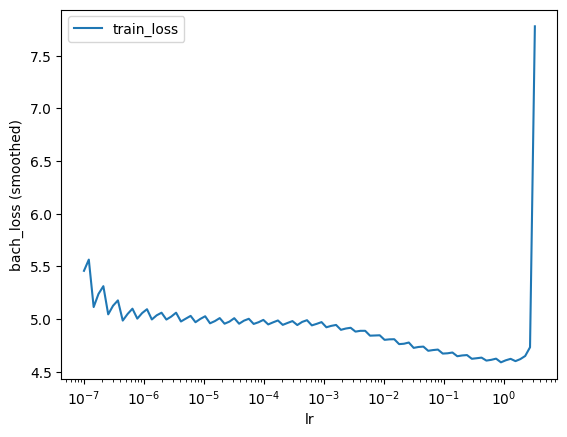

In [14]:
lrfinder = model.lr_finder(x_train, y_train, tolerance=10)
_ = lrfinder.plot()

In [15]:
lrfinder.get_best_lr()

np.float64(0.08902150854450441)

In [16]:
model.optimizer.set_lr(0.01)

In [17]:
epochs = 512
callbacks = [tt.callbacks.EarlyStopping()]
verbose = True

In [18]:
batch_size = 256

In [19]:
%%time
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, verbose,
                val_data=val, val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.6743,	val_loss: 4.3458
1:	[0s / 0s],		train_loss: 4.3699,	val_loss: 4.2667
2:	[0s / 0s],		train_loss: 4.4214,	val_loss: 4.2620
3:	[0s / 0s],		train_loss: 4.2477,	val_loss: 4.2753
4:	[0s / 0s],		train_loss: 4.2105,	val_loss: 4.2894
5:	[0s / 0s],		train_loss: 4.2324,	val_loss: 4.2918
6:	[0s / 0s],		train_loss: 4.1994,	val_loss: 4.2890
7:	[0s / 0s],		train_loss: 4.1967,	val_loss: 4.2929
8:	[0s / 0s],		train_loss: 4.1245,	val_loss: 4.2908
9:	[0s / 0s],		train_loss: 4.1723,	val_loss: 4.2897
10:	[0s / 0s],		train_loss: 4.2113,	val_loss: 4.2813
11:	[0s / 0s],		train_loss: 4.3296,	val_loss: 4.2758
12:	[0s / 0s],		train_loss: 4.2936,	val_loss: 4.2762
CPU times: user 214 ms, sys: 40.9 ms, total: 255 ms
Wall time: 97.4 ms


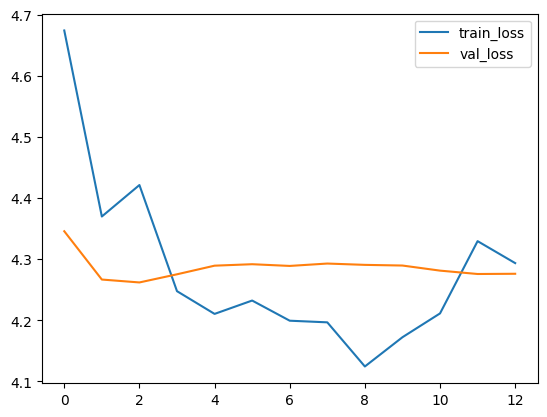

In [20]:
_ = log.plot()

In [21]:
model.partial_log_likelihood(*val).mean()

np.float32(-4.7458773)

## Prediction

In [22]:
_ = model.compute_baseline_hazards()

In [23]:
surv = model.predict_surv_df(x_test)

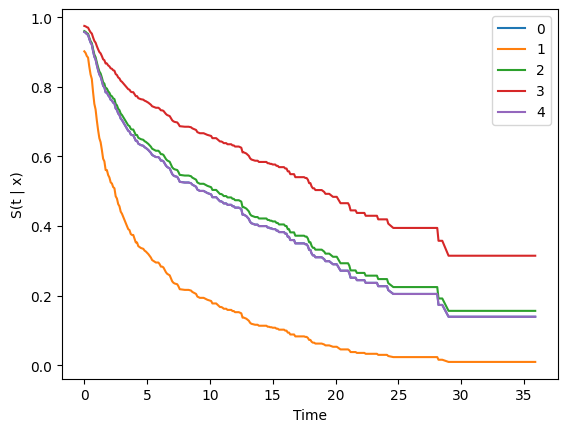

In [24]:
surv.iloc[:, :5].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel('Time')

## Evaluation


In [25]:
ev = EvalSurv(surv, time_tests, status_tests, censor_surv='km')

In [26]:
ev.concordance_td()

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


0.539493193152716

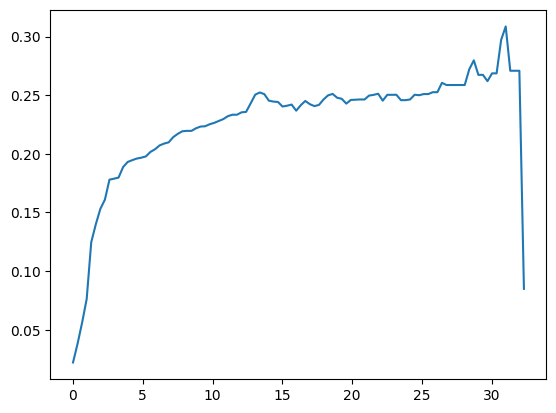

In [27]:
time_grid = np.linspace(time_tests.min(), time_tests.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [28]:
ev.integrated_brier_score(time_grid)

np.float64(0.22845175476357185)

In [29]:
ev.integrated_nbll(time_grid)

np.float64(0.6442304667766604)

<Axes: >

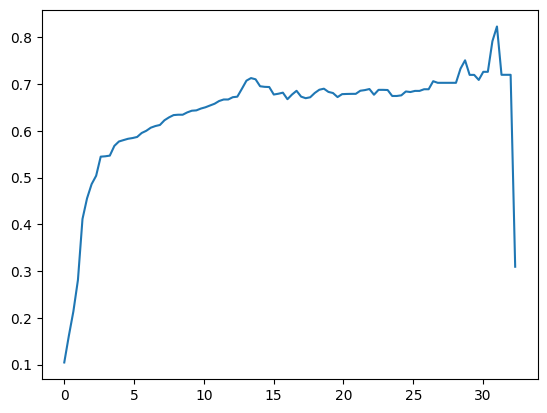

In [30]:
ev.nbll(time_grid).plot()